In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [69]:
# Load data 

hydrogen_data = pd.read_csv("/Users/benleon/Physics Projs/Phys 20CL/data/hydrogen_data.csv")
helium_data = pd.read_csv("/Users/benleon/Physics Projs/Phys 20CL/data/helium_data.csv")

# Relevant Parameters

m_hydro, m_helium = hydrogen_data["m"], helium_data["m"] # Diffraction order
theta_hydro, theta_helium = np.deg2rad(hydrogen_data["Degrees"]), np.deg2rad(helium_data["Degrees"]) # Measured angle of the principle maximum
lamda_helium = helium_data["Lamda"] # Wavelength of Incident Light
theta_o = np.deg2rad(217.150) # Measured angle of central maximum (angle of incident light) 


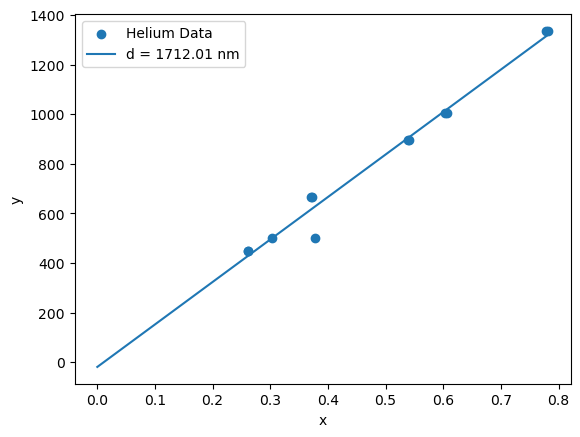

The estimated grated spacing using a linear fit is d = 1712.01 nm which corresponds to approximately 584 lines per mm. The error comparing to the standard value is 2.72 %.


In [176]:
# Part 1 -- Determination of The Grating Spacing for Helium Spectrum

y_vals = m_helium * (lamda_helium) / 10
x_vals = np.abs(np.sin(np.abs(theta_helium - theta_o)))


# Plot and Least-Square Fit

dfit, intercept = np.polyfit(x_vals, y_vals, 1)
xfit = np.linspace(0, x_vals.max(), 100)
yfit = dfit * xfit + intercept
plt.scatter(x_vals, y_vals, label = 'Helium Data')
plt.plot(xfit , yfit, label = f"d = {dfit:.2f} nm" )
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.savefig("/Users/benleon/Physics Projs/Phys 20CL/plots/helium_plot.png")
plt.show()

# Compare to manufacturer value of d
d_error = (np.abs(dfit - (10**6/600)) / (10**6/600)) * 100

print(f"The estimated grated spacing using a linear fit is d = {dfit:.2f} nm which corresponds to approximately 584 lines per mm. The error comparing to the standard value is {d_error:.2f} %.")

In [177]:
# Part 2 -- Calculaton of Wavelengths Using Grating Spacing

# Compute wavelengths for each spectral line
lamda_i = (dfit * 1e-9) * (np.sin(np.abs(theta_hydro - theta_o))) / m_hydro

# n values for transitions between energy levels
n_i = np.array([5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3,])

#compute rydberg constant for each wavelength and transition
n_air = 1.00029
lamda_vac_i = n_air * lamda_i
rydberg_i = (1 / lamda_vac_i) / ((1 / 4) - (1 / n_i**2))
R_avg = np.mean(rydberg_i)
R_std = np.std(rydberg_i, ddof = 1)
R_sem = R_std / np.sqrt(len(rydberg_i))
R_error = (np.abs(R_avg - 10973731.568157) / 10973731.568) * 100

# Comparison of wavelengths to standard values
standard_nm = {
    "H_alpha": 656.285,
    "H_beta": 486.136,
    "H_gamma": 434.046
}
avg_lamda_gamma = sum(lamda_i[0:6]) / 6
avg_lamda_beta = sum(lamda_i[6:12]) / 6
avg_lamda_alpha = sum(lamda_i[12:16]) / 4
lamda_error_gamma = np.abs(((avg_lamda_gamma*1e9 - 434.046) / 434.046) * 100) 
lamda_error_beta = np.abs(((avg_lamda_beta*1e9 - 486.135) / 486.135) * 100)
lamda_error_alpha = np.abs(((avg_lamda_alpha*1e9 - 656.285) / 656.285) * 100) 

print("Spectral Line Wavelengths")
print(f" For the gamma balmer line, lamda = {avg_lamda_gamma*1e9:.2f} nm with an error of {lamda_error_gamma:.1f} %.") 
print(f" For the beta balmer line, lamda = {avg_lamda_beta*1e9:.2f} nm with an error of {lamda_error_beta:.1f} %.") 
print(f" For the alpha balmer line, lamda ={avg_lamda_alpha*1e9:.2f} nm with an error of {lamda_error_alpha:.1f} %.") 

print("\n")
print(f"The estimated value of the Rydberg constant from experimental data is R = {R_avg:.2f} +- {R_sem:.2f} m^-1 with an error of {R_error:.2f} compared to the standard value. ")

Spectral Line Wavelengths
 For the gamma balmer line, lamda = 436.23 nm with an error of 0.5 %.
 For the beta balmer line, lamda = 491.92 nm with an error of 1.2 %.
 For the alpha balmer line, lamda =663.90 nm with an error of 1.2 %.


The estimated value of the Rydberg constant from experimental data is R = 10874307.90 +- 72812.20 m^-1 with an error of 0.91 compared to the standard value. 
